## E-Commerce Sales and Customer Behavior Analysis

### Step 1

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [51]:
df = pd.read_excel(r"C:\Users\Admin\Desktop\github\python-data-science-handbook\Projects\data\online_retail_II.xlsx")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [52]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [53]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [54]:
 # df.dropna(["CustomerID"])

In [55]:
df.dropna(subset=["Customer ID", "Description"], inplace=True)

In [56]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [57]:
# Filter Anomalies 
# Remove cancel orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [58]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [59]:
df[((df["Quantity"] <= 0) | (df["Price"] <= 0))]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


## Phase 2: Feature Engineering

In [60]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407695 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407695 non-null  object        
 1   StockCode    407695 non-null  object        
 2   Description  407695 non-null  object        
 3   Quantity     407695 non-null  int64         
 4   InvoiceDate  407695 non-null  datetime64[ns]
 5   Price        407695 non-null  float64       
 6   Customer ID  407695 non-null  float64       
 7   Country      407695 non-null  object        
 8   TotalAmount  407695 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.1+ MB


In [62]:
df["Month"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour

## Phase 3: Exploratory Data Analysis

In [68]:
df["revenue"] = df["TotalAmount"] - df["Price"]
top_revenue = df.sort_values(by="revenue", ascending=False).iloc[:10]
top_quantity = df.sort_values(by="Quantity", ascending=False).iloc[:10]
top_quantity
top_revenue

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month,DayOfWeek,Hour,revenue
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.40,11,3,11,15816.71
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,8925.00,6,1,12,8922.45
379875,525968,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,3120,2010-10-08 10:10:00,1.66,15838.0,United Kingdom,5179.20,10,4,10,5177.54
358821,524181,21622,VINTAGE UNION JACK CUSHION COVER,648,2010-09-27 16:59:00,6.89,17450.0,United Kingdom,4464.72,9,0,16,4457.83
452200,532358,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2010-11-11 17:05:00,1.45,12931.0,United Kingdom,4176.00,11,3,17,4174.55
420628,529613,22423,REGENCY CAKESTAND 3 TIER,360,2010-10-29 10:46:00,10.95,17949.0,United Kingdom,3942.00,10,4,10,3931.05
390762,526934,22790,"MIRROR, ARCHED GEORGIAN",200,2010-10-14 09:46:00,19.42,18102.0,United Kingdom,3884.00,10,3,9,3864.58
358823,524181,21624,VINTAGE UNION JACK DOORSTOP,648,2010-09-27 16:59:00,5.96,17450.0,United Kingdom,3862.08,9,0,16,3856.12
519376,537659,21623,VINTAGE UNION JACK MEMOBOARD,600,2010-12-07 16:43:00,6.38,18102.0,United Kingdom,3828.00,12,1,16,3821.62
522809,537899,22328,ROUND SNACK BOXES SET OF 4 FRUITS,1488,2010-12-09 10:44:00,2.55,12755.0,Japan,3794.40,12,3,10,3791.85


In [69]:
top_customers = df.sort_values(by="TotalAmount", ascending=False).iloc[:5]
top_customers

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month,DayOfWeek,Hour,revenue
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,15818.4,11,3,11,15816.71
135013,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,10953.5,3,1,15,0.00
358639,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,10468.8,9,0,16,0.00
74356,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,8985.6,1,4,11,0.00
228042,511465,15044A,PINK PAPER PARASOL,3500,2010-06-08 12:59:00,2.55,18008.0,United Kingdom,8925.0,6,1,12,8922.45


In [75]:
country_revenue = df[~(df["Country"] == "United Kingdom")]
country_revenue_mean = country_revenue.groupby("Country").mean(numeric_only=True)
country_revenue_mean.sort_values(by="revenue", ascending=False).iloc[:5]

,Quantity,Price,Customer ID,TotalAmount,Month,DayOfWeek,Hour,revenue
Country,,,,,,,,
Denmark,549.497608,2.589522,12820.765550,121.786722,6.961722,2.143541,12.545455,119.197201
Netherlands,67.282051,2.719593,13994.242125,98.456410,7.258242,2.214286,12.173260,95.736817
Japan,44.579268,1.924085,12778.554878,59.280610,7.000000,2.146341,11.317073,57.356524
Sweden,60.402074,5.479885,13105.520737,61.257362,6.748848,2.056452,11.966590,55.777477
Australia,32.046032,4.630746,12480.265079,49.915556,8.296825,1.860317,11.939683,45.284810


## Phase 4: Data Visualization

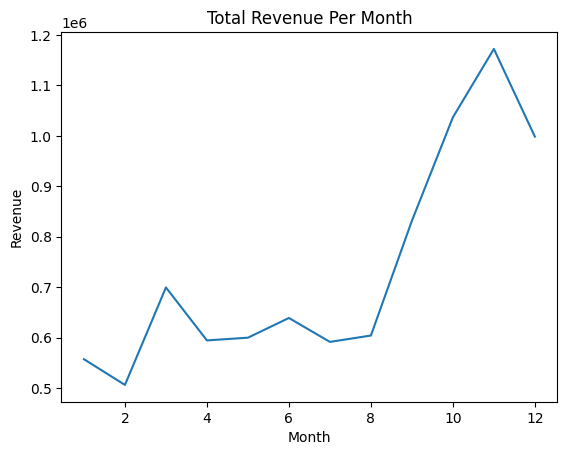

In [ ]:
monthly_sales = df.groupby("Month")["TotalAmount"].sum()
plt.plot(monthly_sales.index, monthly_sales.values)

plt.title("Total Revenue Per Month")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

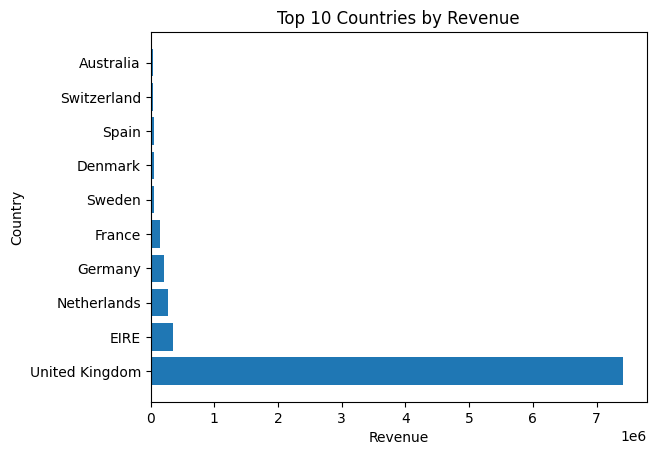

In [83]:
top_countries = df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10)
plt.barh(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")


plt.show()

Text(0, 0.5, 'Hours')

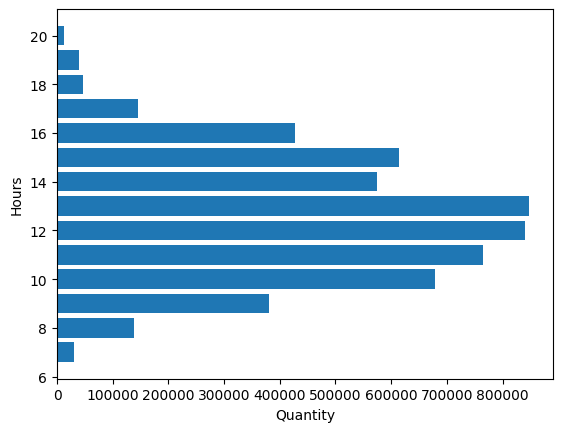

In [113]:
# Peak Traffic (Bar Chart): Plot the number of orders by the Hour of the day to see when customers are most active on the site
hour_orders = df.groupby("Hour")["Quantity"].sum()
plt.barh(hour_orders.index, hour_orders.values)
plt.xlabel("Quantity")
plt.ylabel("Hours")

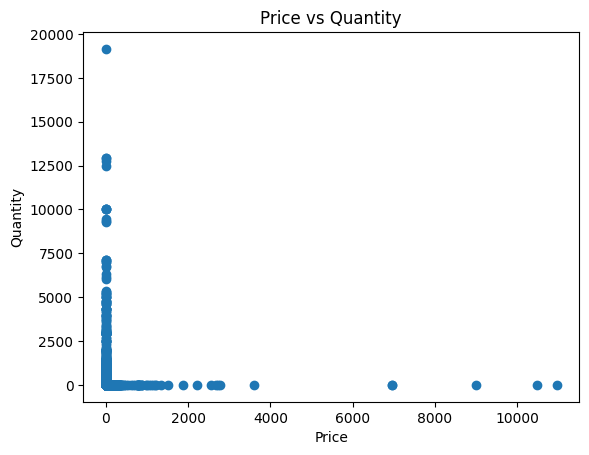

In [84]:
plt.scatter(df["Price"], df["Quantity"])
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show()

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month,DayOfWeek,Hour,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,12,1,7,76.45
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12,1,7,74.25
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12,1,7,74.25
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,12,1,7,98.70
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,12,1,7,28.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,12,3,20,2.95
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,12,3,20,0.00
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,12,3,20,0.00
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,12,3,20,3.75


<Axes: xlabel='Price', ylabel='Count'>

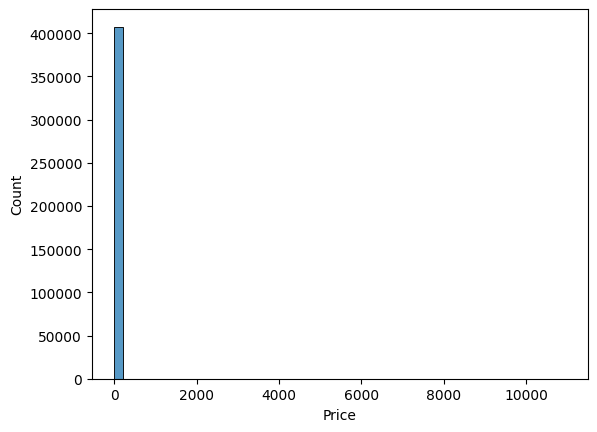

In [92]:
import seaborn as sns
sns.histplot(df["Price"], bins=50)

In [95]:
df["Price"].quantile(0.99)

np.float64(14.95)

In [106]:
filtered_df = df[(df["Quantity"]<= 144)]
filtered_df = filtered_df[filtered_df["Price"] <= 15]
filtered_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Month,DayOfWeek,Hour,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,12,1,7,76.45
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12,1,7,74.25
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,12,1,7,74.25
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,12,1,7,98.70
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,12,1,7,28.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,12,3,20,2.95
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,12,3,20,0.00
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,12,3,20,0.00
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,12,3,20,3.75


<Axes: xlabel='Price', ylabel='Count'>

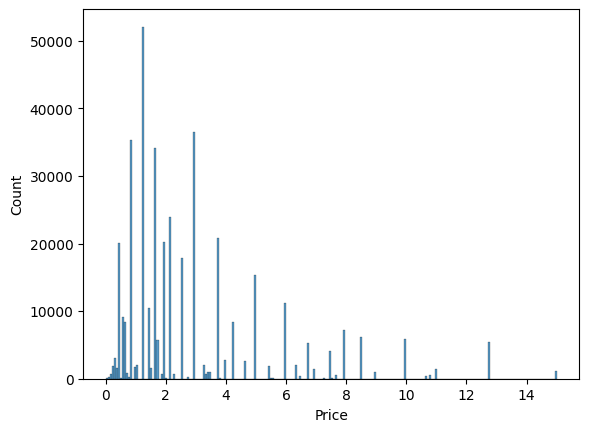

In [107]:
sns.histplot(filtered_df["Price"])

Text(0, 0.5, 'Quantity')

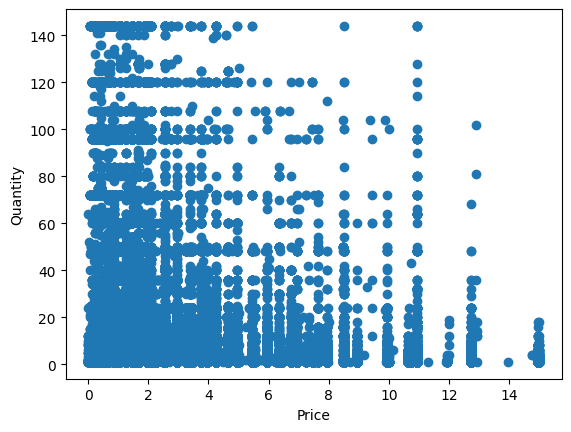

In [109]:
plt.scatter(filtered_df["Price"], filtered_df["Quantity"])
plt.xlabel("Price")
plt.ylabel("Quantity")

In [102]:
filtered_df["Quantity"].max()

np.int64(19152)